In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt

path='/content/drive/MyDrive/Colab Notebooks/abalone.csv'
df = pd.read_csv(path)

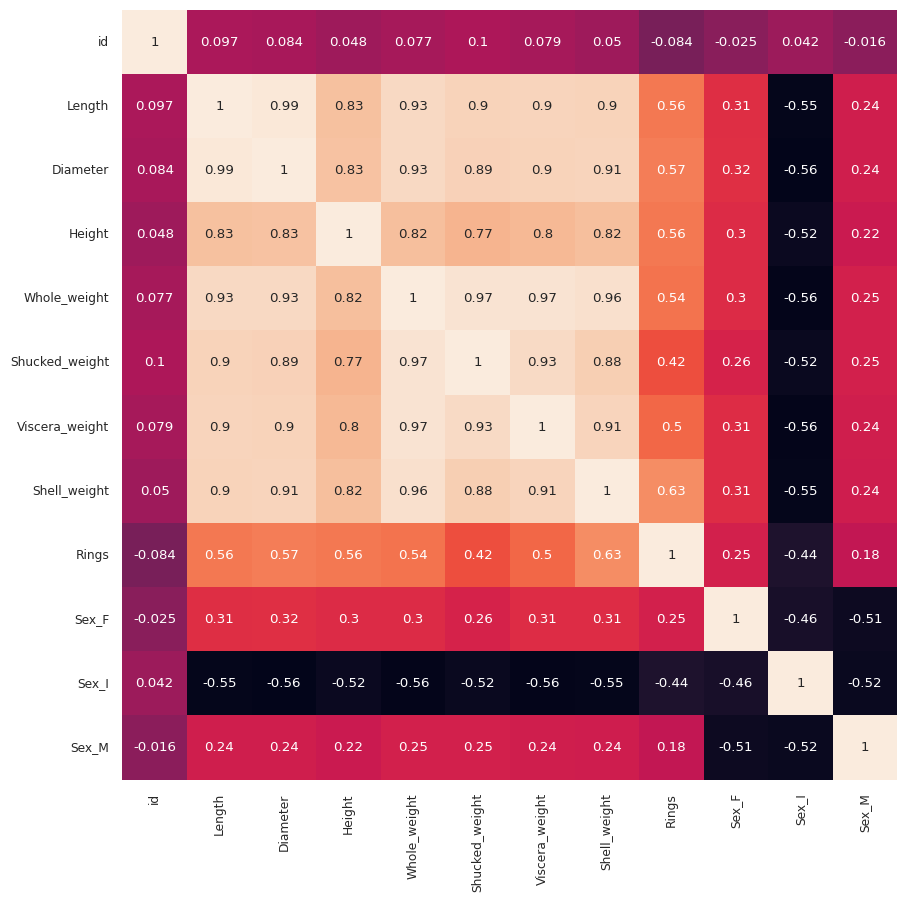

In [6]:
df_encoded = pd.get_dummies(df)
df_corr = df_encoded.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df_encoded.drop('Rings',axis=1)
X = X.values
print(X.shape)


(4177, 11)


In [13]:
y = df['Rings']
Y = y.values

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 1. fit_transform: 훈련 데이터의 평균과 표준편차를 '계산(fit)'하고 바로 '변환(transform)'합니다. 모든 데이터를 평균을 0 표준편차는 1로 변신
X_train = scaler.fit_transform(X_train)

# 2. transform: 중요! 훈련 데이터에서 구한 '그 기준 그대로' 테스트 데이터도 변환합니다.
# (테스트 데이터로 새로 계산하면 안 돼요. 시험 문제는 공부한 기준대로 풀어야 하니까요!)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((3341, 11), (3341,), (836, 11), (836,))

In [17]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

#입력 컬럼이 11개임
model.add(Dense(8,input_shape=(11,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))
#결과가 1개이므로 마지막은 1로 끝남

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,327 (5.18 KB)

 Trainable params: 1,327 (5.18 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
N_EPOCHS = 30

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 64.4725 - mse: 64.4725 - val_loss: 22.0094 - val_mse: 22.0094
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 13.8387 - mse: 13.8387 - val_loss: 8.5942 - val_mse: 8.5942
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.5408 - mse: 8.5408 - val_loss: 6.2284 - val_mse: 6.2284
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.0047 - mse: 7.0047 - val_loss: 5.7075 - val_mse: 5.7075
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.3989 - mse: 6.3989 - val_loss: 5.3994 - val_mse: 5.3994
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.9973 - mse: 5.9973 - val_loss: 5.3895 - val_mse: 5.3895
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7209 - mse: 5.7209 - val_loss: 5.2680 - val_mse: 5.2680
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4999 - mse: 5.4999 - val_loss: 5.2647 - val_mse: 5.2647
Epoch 9/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

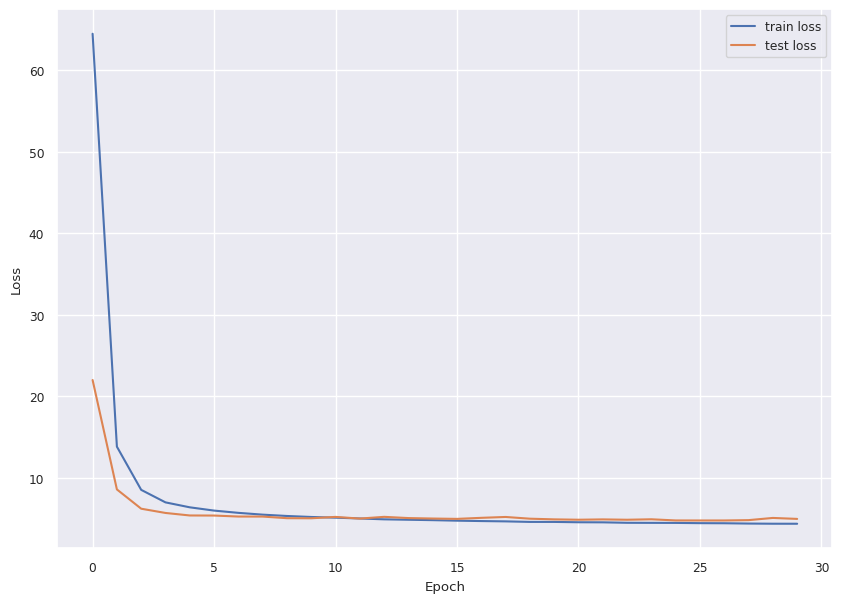

In [19]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9780 - mse: 4.9780


[4.978025436401367, 4.978025436401367]